In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np 
import sqlite3 as sql 
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

crime=pd.read_csv("processed_data/crime_module_1.csv")
demo=pd.read_csv("processed_data/demography_module_2.csv")
economy=pd.read_csv("processed_data/Economy_module_3.csv")

data=crime.merge(demo,on="district_name")
data = data.merge(economy,on="district_name")

data = data.drop(columns=["population_y", "Area"])
data = data.rename(columns={"population_x": "population"})
data=data.drop(columns=["employment_rate"])

data
                   

,district_name,property_crime,violent_crime,women_crime,social_crime,public_safety,total_crimes,population,area,population_density,sex_ratio,literacy,total_workers,non_workers,WPR,establishments,persons_employed,employment_per_establishment,establishment_density
0,Central,7762,474,441,14,1595,12149,582320,21,27729.523810,892,85.14,207374,374946,35.611691,150671,599058,3.98,7174.81
1,East,16011,1051,1049,14,956,21789,1709346,63,27132.476190,884,89.31,579692,1129654,33.913087,151799,445642,2.94,2409.51
2,New Delhi,6108,153,348,2,385,8316,142004,35,4057.257143,822,88.34,59541,82463,41.929101,38153,269225,7.06,1090.09
3,North,8212,425,361,9,964,11438,887978,61,14557.016393,869,86.85,296446,591532,33.384386,73724,318960,4.33,1208.59
4,North East,13711,1458,1215,27,773,20338,2241624,62,36155.225806,886,83.12,655398,1564699,29.237642,86597,183313,2.12,1396.73
5,North West,41857,2701,2426,49,3244,55707,3656539,443,8254.038375,865,84.74,1121005,2321536,30.657543,93297,286189,3.07,210.60
6,South,28694,2280,2241,33,2139,40089,2731929,247,11060.441296,862,86.57,924393,1807536,33.836641,132175,497866,3.77,535.12
7,South West,8395,1110,887,15,1085,13207,2292958,421,5446.456057,840,88.28,795352,1497606,34.686723,42166,105954,2.51,100.16
8,West,19523,1255,1258,19,1354,26486,2543243,130,19563.407692,875,86.98,874320,1668923,34.378154,106726,313574,2.94,820.97


In [3]:

data.info()
data.isnull().sum()
data.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   district_name                 9 non-null      str    
 1   property_crime                9 non-null      int64  
 2   violent_crime                 9 non-null      int64  
 3   women_crime                   9 non-null      int64  
 4   social_crime                  9 non-null      int64  
 5   public_safety                 9 non-null      int64  
 6   total_crimes                  9 non-null      int64  
 7   population                    9 non-null      int64  
 8   area                          9 non-null      int64  
 9   population_density            9 non-null      float64
 10  sex_ratio                     9 non-null      int64  
 11  literacy                      9 non-null      float64
 12  total_workers                 9 non-null      int64  
 13  non_workers         

,count,mean,std,min,25%,50%,75%,max
property_crime,9.0,1.669700e+04,1.187016e+04,6108.000000,8212.000000,1.371100e+04,1.952300e+04,4.185700e+04
violent_crime,9.0,1.211889e+03,8.471960e+02,153.000000,474.000000,1.110000e+03,1.458000e+03,2.701000e+03
women_crime,9.0,1.136222e+03,7.648867e+02,348.000000,441.000000,1.049000e+03,1.258000e+03,2.426000e+03
social_crime,9.0,2.022222e+01,1.414901e+01,2.000000,14.000000,1.500000e+01,2.700000e+01,4.900000e+01
public_safety,9.0,1.388333e+03,8.584276e+02,385.000000,956.000000,1.085000e+03,1.595000e+03,3.244000e+03
total_crimes,9.0,2.327989e+04,1.559138e+04,8316.000000,12149.000000,2.033800e+04,2.648600e+04,5.570700e+04
population,9.0,1.865327e+06,1.136825e+06,142004.000000,887978.000000,2.241624e+06,2.543243e+06,3.656539e+06
area,9.0,1.647778e+02,1.659192e+02,21.000000,61.000000,6.300000e+01,2.470000e+02,4.430000e+02
population_density,9.0,1.710620e+04,1.123565e+04,4057.257143,8254.038375,1.455702e+04,2.713248e+04,3.615523e+04
sex_ratio,9.0,8.661111e+02,2.269055e+01,822.000000,862.000000,8.690000e+02,8.840000e+02,8.920000e+02


In [4]:
data.loc[data["total_crimes"].idxmax(), ["district_name", "total_crimes"]]
data[["district_name","total_crimes"]].sort_values(by="total_crimes",ascending=False)

,district_name,total_crimes
5,North West,55707
6,South,40089
8,West,26486
1,East,21789
4,North East,20338
7,South West,13207
0,Central,12149
3,North,11438
2,New Delhi,8316


In [5]:
def plot_bar_graph(x_value,y_value):
    plt.figure(figsize=(12,7))
    bars = plt.bar(data[x_value],data[y_value])
    plt.xlabel(x_value.replace("_"," ").title())
    plt.ylabel(y_value.replace("_"," ").title())
    plt.title(f"{y_value.replace('_',' ').title()} by District")
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + height * 0.01,
                 f"{int(height):,}",
                 ha= "center",
                 fontsize=9
                 )
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()
        


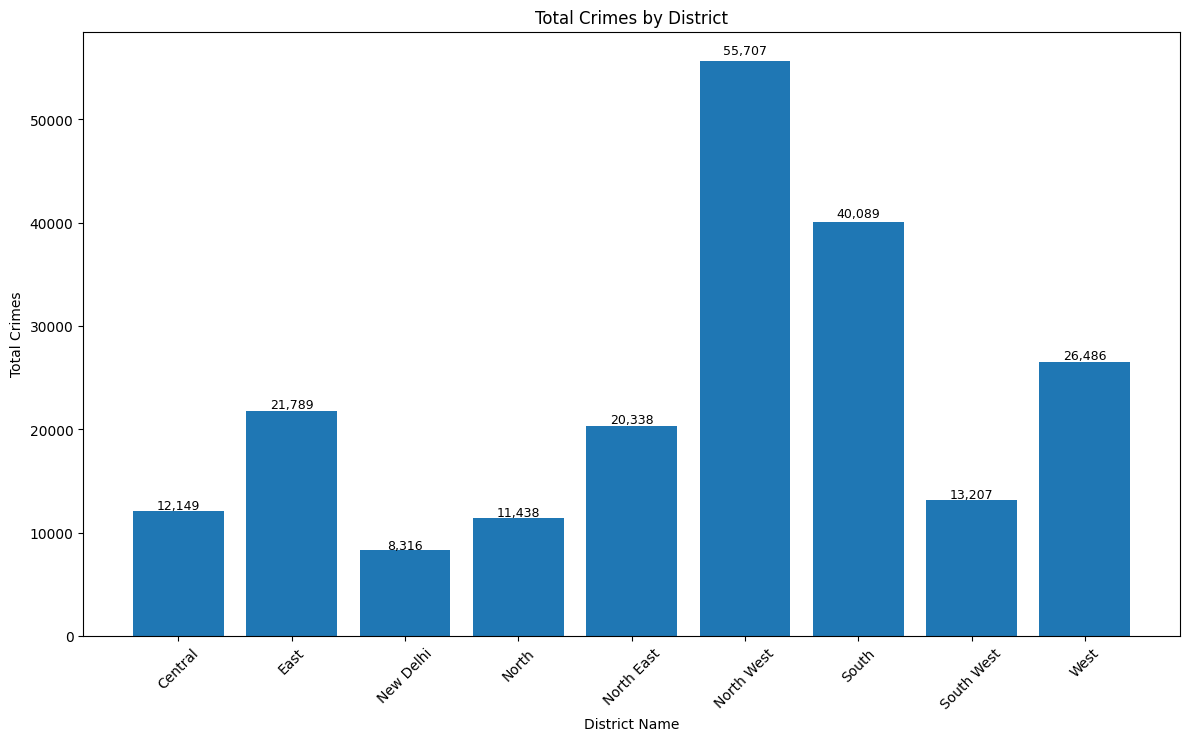

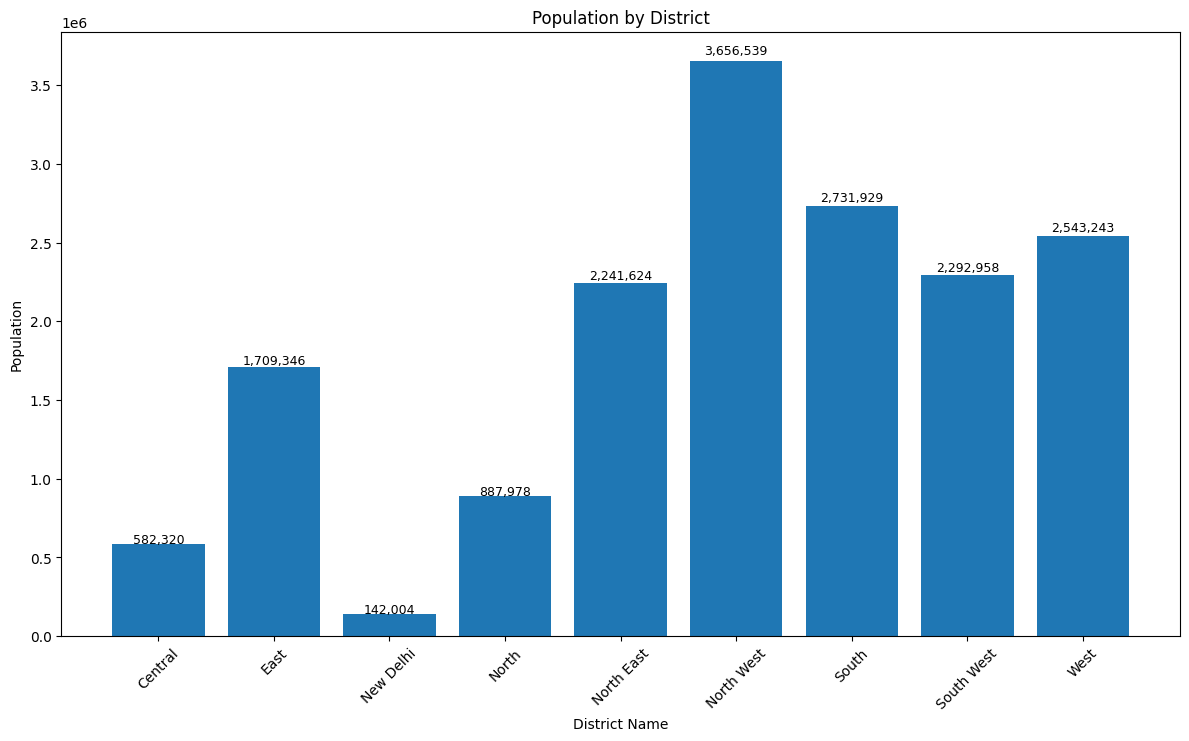

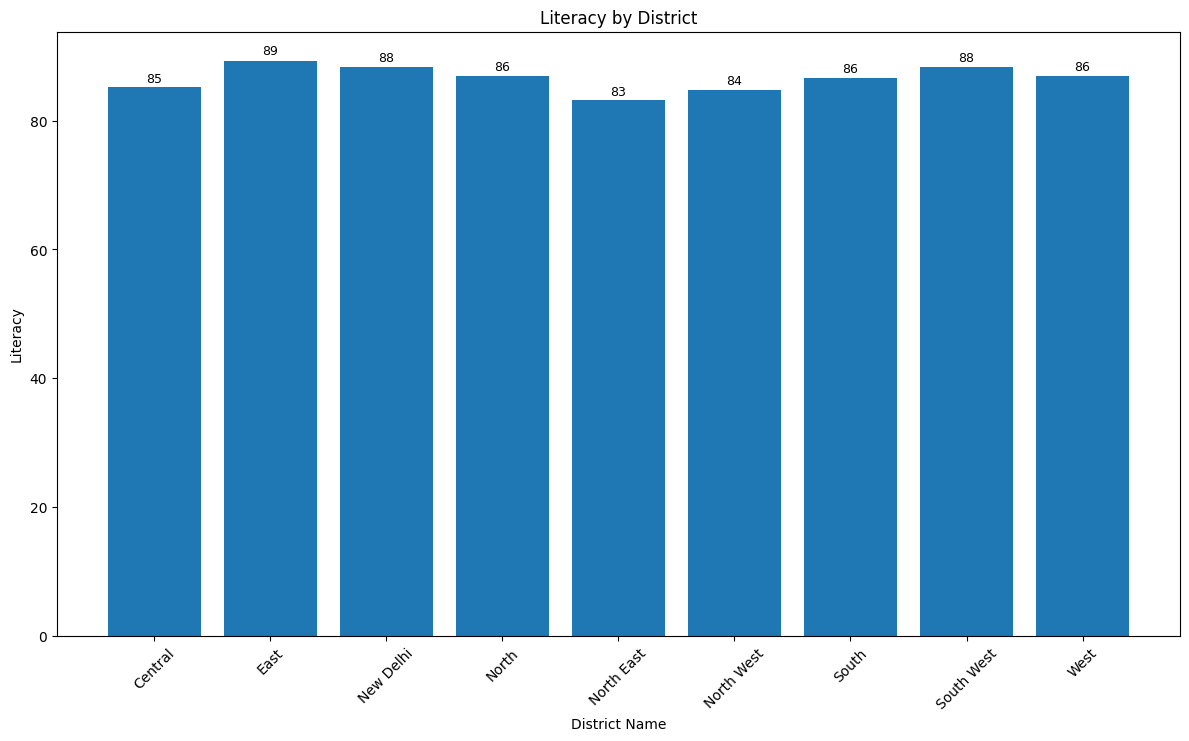

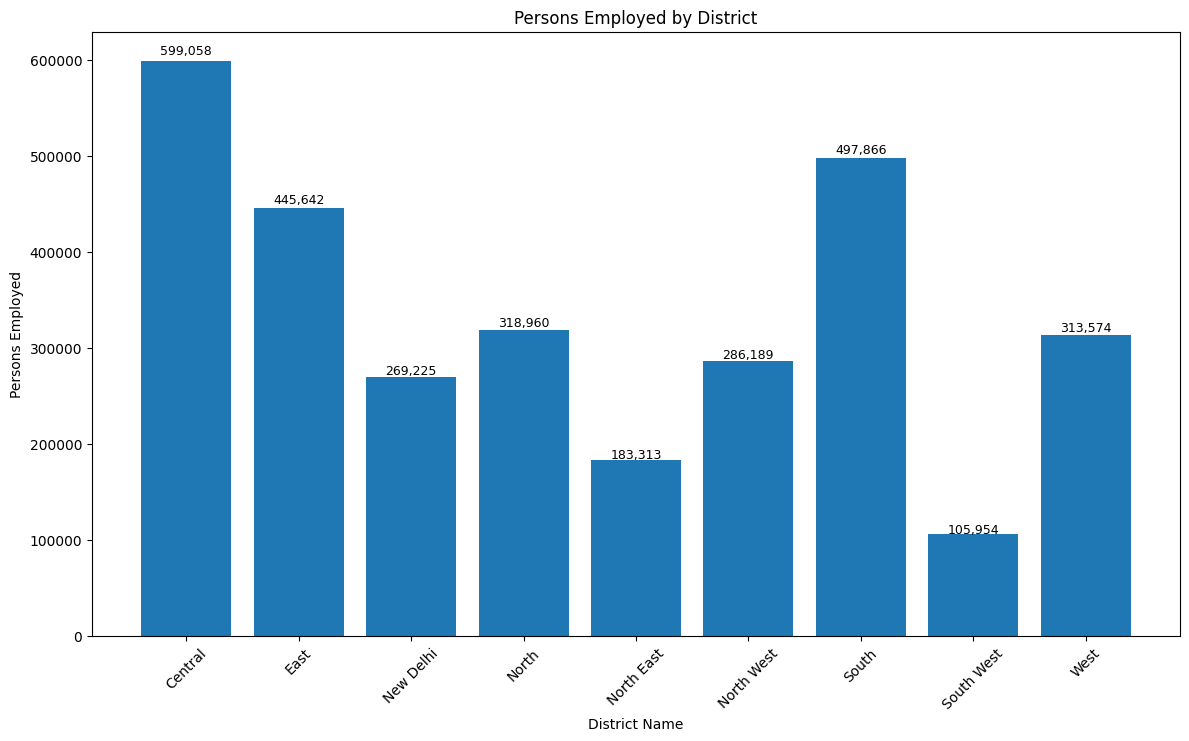

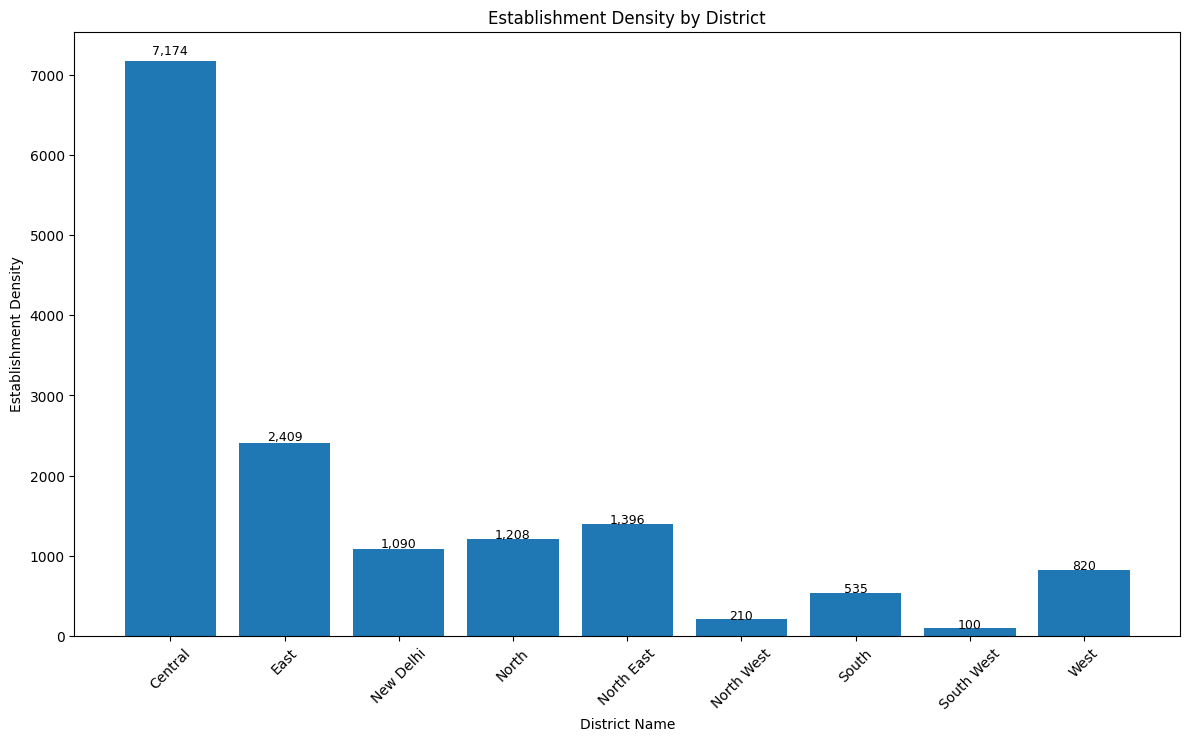

In [6]:
plot_bar_graph("district_name","total_crimes")
plot_bar_graph("district_name","population")
plot_bar_graph("district_name","literacy")
plot_bar_graph("district_name","persons_employed")
plot_bar_graph("district_name","establishment_density")

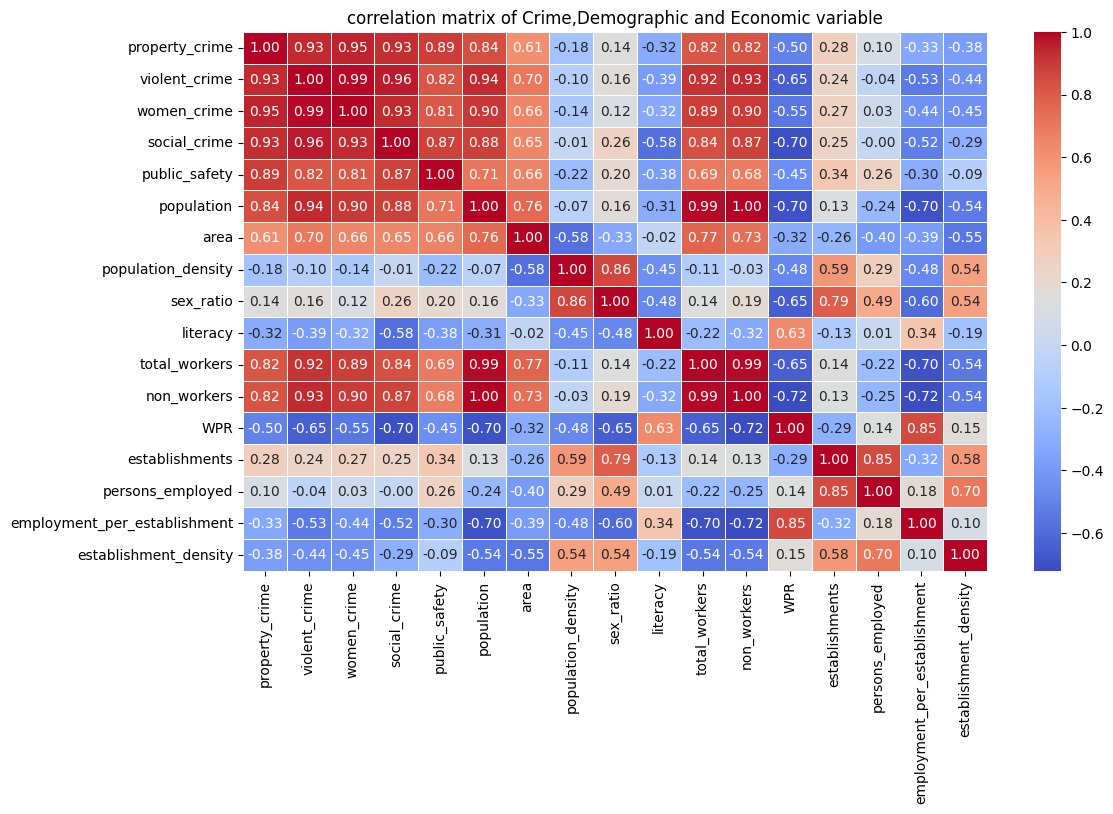

In [7]:
data= data.drop(columns=["total_crimes"])
corr = data.corr(numeric_only=True)
corr
plt.figure(figsize=(12,7))

sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths= 0.5)
plt.title("correlation matrix of Crime,Demographic and Economic variable")
plt.show()

In [8]:
normalization = data.copy()
for n in normalization.columns[1:]:
    mean = normalization[n].mean()
    std = normalization[n].std()

    normalization[n] = (normalization[n]-mean)/std
normalization

normalization.describe().T

,count,mean,std,min,25%,50%,75%,max
property_crime,9.0,0.000000e+00,1.0,-0.892069,-0.714817,-0.251555,0.238076,2.119600
violent_crime,9.0,-1.133353e-16,1.0,-1.249875,-0.870978,-0.120266,0.290501,1.757694
women_crime,9.0,1.326100e-16,1.0,-1.030508,-0.908922,-0.114033,0.159210,1.686234
social_crime,9.0,1.187322e-16,1.0,-1.287880,-0.439764,-0.369088,0.479028,2.033908
public_safety,9.0,1.326100e-16,1.0,-1.168804,-0.503634,-0.353359,0.240750,2.161704
population,9.0,-2.467162e-17,1.0,-1.515909,-0.859718,0.331007,0.596324,1.575627
area,9.0,4.009139e-17,1.0,-0.866553,-0.625472,-0.613418,0.495556,1.676853
population_density,9.0,1.727014e-16,1.0,-1.161387,-0.787864,-0.226884,0.892362,1.695408
sex_ratio,9.0,1.097887e-15,1.0,-1.944030,-0.181182,0.127317,0.788385,1.140955
literacy,9.0,-5.581955e-15,1.0,-1.760969,-0.736508,0.130734,0.855972,1.378346


In [9]:
pca = PCA(n_components=2)
X = normalization.drop(columns = ["district_name"])

principal_component = pca.fit_transform(X)

pca.explained_variance_ratio_


array([0.53225406, 0.24547299])

In [10]:
loadings = pd.DataFrame(pca.components_.T,
                        columns = ["PC1","PC2"],
                        index=X.columns)
print(loadings)
pca_df = pd.DataFrame(
    principal_component,
    columns=["PC1", "PC2"]
)

pca_df["district_name"] = normalization["district_name"]

pca_df


                                   PC1       PC2
property_crime                0.299263 -0.017396
violent_crime                 0.324605 -0.019472
women_crime                   0.312791 -0.027441
social_crime                  0.318178  0.038310
public_safety                 0.269696  0.032626
population                    0.324669 -0.052594
area                          0.241983 -0.259269
population_density           -0.010524  0.429881
sex_ratio                     0.081906  0.458425
literacy                     -0.141240 -0.213432
total_workers                 0.317491 -0.064891
non_workers                   0.323388 -0.042694
WPR                          -0.247631 -0.193913
establishments                0.073392  0.408020
persons_employed             -0.038285  0.328533
employment_per_establishment -0.220687 -0.170972
establishment_density        -0.142378  0.371833


,PC1,PC2,district_name
0,-2.471596,3.434801,Central
1,-0.652470,1.586031,East
2,-4.770387,-2.782017,New Delhi
3,-2.267739,-0.130256,North
4,1.067178,1.590082,North East
5,5.377642,-0.933312,North West
6,2.674323,-0.096502,South
7,0.206138,-2.808240,South West
8,0.836911,0.139413,West


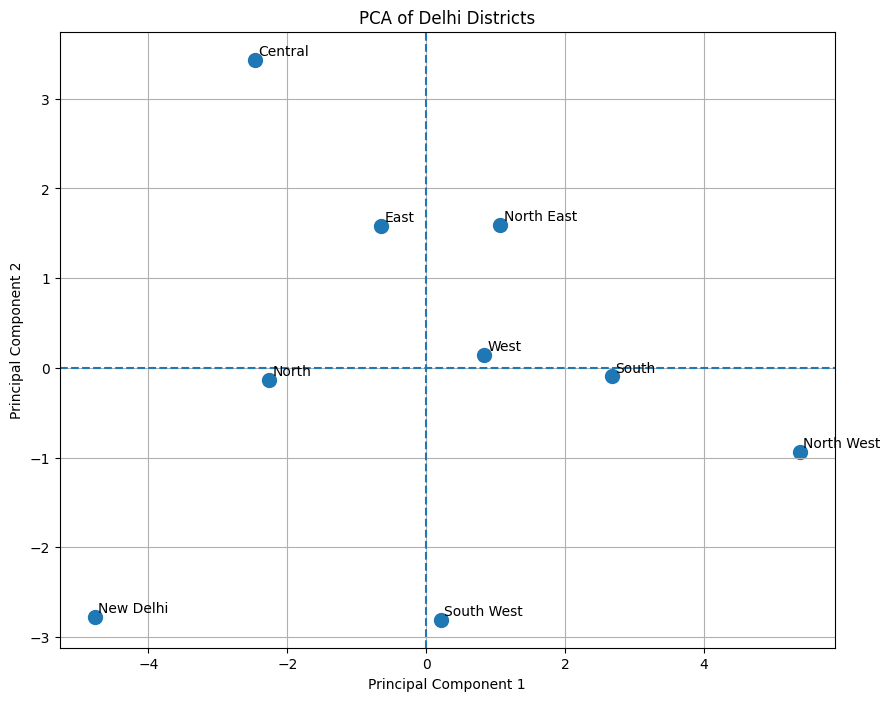

In [11]:
plt.figure(figsize=(10,8))

plt.scatter(pca_df["PC1"], pca_df["PC2"], s=100)

for i in range(len(pca_df)):
    plt.text(
        pca_df.loc[i, "PC1"] + 0.05,
        pca_df.loc[i, "PC2"] + 0.05,
        pca_df.loc[i, "district_name"],
        fontsize=10
    )

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Delhi Districts")

plt.grid(True)
plt.show()